🔍 Scanning dataset at: ..\dataset_collection\roboflow\object_detection\object_detection_all_class...

   📂 Found split: train
   📂 Found split: valid
   📂 Found split: test


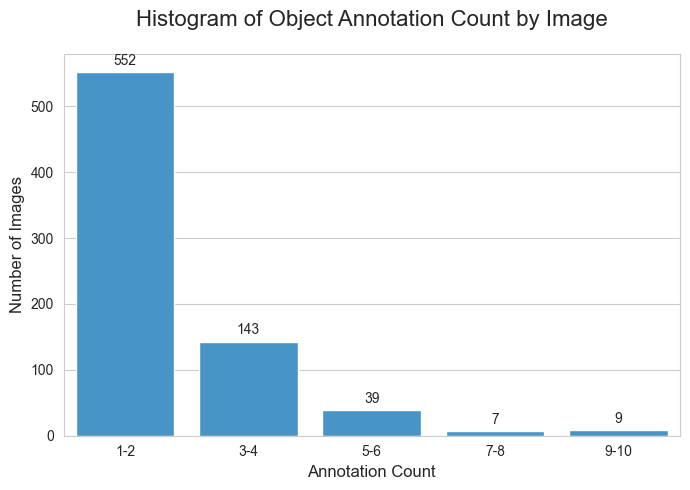

--------------------------------------------------
✅ Analysis Complete!
📊 Total Images Analyzed : 750
📈 Avg Objects/Image     : 1.98
🔼 Max Objects/Image     : 10
🔽 Min Objects/Image     : 1
💾 Chart saved at        : visualization_chart\object_count_histogram\object_count_binned_distribution.png
--------------------------------------------------


In [9]:
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
import numpy as np

def visualize_binned_object_count(input_path_folder, output_path_folder):
    """
    Calculates and visualizes the histogram of object counts per image with binned categories (1-2, 3-4, etc.).
    """
    
    # 1. Setup Path
    input_path = Path(input_path_folder)
    output_path = Path(output_path_folder)
    output_path.mkdir(parents=True, exist_ok=True)
    
    splits = ['train', 'valid', 'val', 'test']
    all_counts = []
    total_images_checked = 0
    
    print(f"🔍 Scanning dataset at: {input_path}...\n")

    # 2. Iterate through splits and read labels
    for split in splits:
        label_dir = input_path / split / 'labels'
        
        if not label_dir.exists():
            continue
            
        print(f"   📂 Found split: {split}")
        label_files = glob.glob(str(label_dir / "*.txt"))
        total_images_checked += len(label_files)
        
        for file_path in label_files:
            try:
                with open(file_path, 'r') as f:
                    lines = [line.strip() for line in f.readlines() if line.strip()]
                    all_counts.append(len(lines))
            except Exception as e:
                print(f"⚠️ Error reading {file_path}: {e}")

    if not all_counts:
        print("\n❌ No label files found. Please check the folder structure.")
        return

    # 3. Create DataFrame and Binning Logic
    df = pd.DataFrame(all_counts, columns=['raw_count'])

    def get_bin_label(count):
        """Maps an integer count to a string bin label (e.g., 3 -> '3-4')"""
        if count == 0:
            return "0"
        
        # Calculate the lower bound of the pair (1, 3, 5, etc.)
        # Logic: (1->1, 2->1), (3->3, 4->3)
        lower_bound = ((count - 1) // 2) * 2 + 1
        upper_bound = lower_bound + 1
        return f"{lower_bound}-{upper_bound}"

    # Apply binning
    df['bin_label'] = df['raw_count'].apply(get_bin_label)
    
    # Create a numerical column for proper sorting (so '1-2' comes before '9-10')
    df['sort_key'] = df['raw_count'].apply(lambda x: x if x == 0 else ((x - 1) // 2) * 2 + 1)

    # Count frequency per bin
    plot_data = df.groupby(['bin_label', 'sort_key']).size().reset_index(name='num_images')
    
    # Sort by the numerical key
    plot_data = plot_data.sort_values('sort_key')

    # 4. Visualization
    plt.figure(figsize=(7, 5))
    sns.set_style("whitegrid")
    
    # Create Bar Plot
    ax = sns.barplot(
        data=plot_data,
        x='bin_label',
        y='num_images',
        color='#3498db'
    )
    
    # Chart Cosmetics (English)
    plt.title('Histogram of Object Annotation Count by Image', fontsize=16, pad=20)
    plt.xlabel('Annotation Count', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    
    # Add labels on top of bars
    for i in ax.containers:
        ax.bar_label(i, padding=3)

    plt.tight_layout()
    
    # 5. Save and Show
    filename = "object_count_binned_distribution.png"
    save_full_path = output_path / filename
    plt.savefig(save_full_path, dpi=300)
    
    plt.show()
    
    # 6. Print Statistics (English)
    print("-" * 50)
    print(f"✅ Analysis Complete!")
    print(f"📊 Total Images Analyzed : {total_images_checked}")
    print(f"📈 Avg Objects/Image     : {df['raw_count'].mean():.2f}")
    print(f"🔼 Max Objects/Image     : {df['raw_count'].max()}")
    print(f"🔽 Min Objects/Image     : {df['raw_count'].min()}")
    print(f"💾 Chart saved at        : {save_full_path}")
    print("-" * 50)

# --- EXECUTION ---
input_folder = "../dataset_collection/roboflow/object_detection/object_detection_all_class" 
output_folder = "visualization_chart/object_count_histogram"

visualize_binned_object_count(input_folder, output_folder)

📂 Analyzing Bounding Box at: object_detection_all_class...
📂 Analyzing Mask at: segmentation_mask_leaf_and_lession...


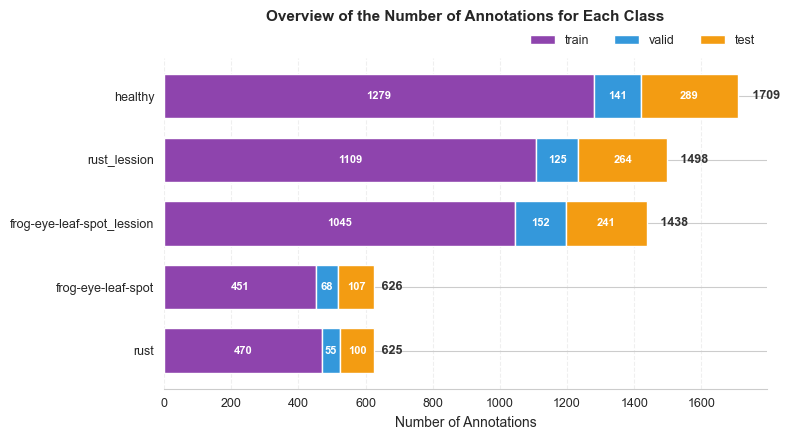

✅ Graph saved at: visualization_chart\class_distribution_analysis\journal_ready_distribution.png


In [18]:
import os
import glob
import yaml
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

def analyze_dataset(dataset_path, dataset_type):
    """
    Membaca dataset YOLO dan menghitung jumlah instance per kelas per split.
    """
    path = Path(dataset_path)
    data_yaml = path / "data.yaml"
    
    # 1. Load Class Names from data.yaml
    class_names = {}
    if data_yaml.exists():
        with open(data_yaml, 'r') as f:
            data = yaml.safe_load(f)
            if isinstance(data['names'], list):
                class_names = {i: name for i, name in enumerate(data['names'])}
            else:
                class_names = data['names']
    else:
        print(f"⚠️ Warning: data.yaml not found in {dataset_path}. Using Class IDs.")
    
    # 2. Count Labels
    splits = ['train', 'valid', 'test']
    records = []
    
    print(f"📂 Analyzing {dataset_type} at: {path.name}...")
    
    for split in splits:
        # Handle 'valid' vs 'val' folder naming
        split_path = path / split / 'labels'
        if not split_path.exists() and split == 'valid':
            split_path = path / 'val' / 'labels'
            
        if not split_path.exists():
            continue
            
        label_files = glob.glob(str(split_path / "*.txt"))
        
        for file_path in label_files:
            try:
                with open(file_path, 'r') as f:
                    lines = f.readlines()
                    for line in lines:
                        if not line.strip(): continue
                        class_id = int(line.split()[0])
                        class_name = class_names.get(class_id, f"Class {class_id}")
                        
                        records.append({
                            "Class": class_name,
                            "Split": split,
                            "Count": 1
                        })
            except Exception:
                pass

    return records

def visualize_journal_ready(obj_det_path, seg_path, output_folder):
    # 1. Collect Data
    data_obj = analyze_dataset(obj_det_path, "Bounding Box")
    data_seg = analyze_dataset(seg_path, "Mask")
    
    all_data = data_obj + data_seg
    
    if not all_data:
        print("❌ No data found.")
        return

    df = pd.DataFrame(all_data)
    
    # 2. Prepare Data Table
    df_grouped = df.groupby(['Class', 'Split']).size().unstack(fill_value=0)
    
    # Ensure columns exist
    for split in ['train', 'valid', 'test']:
        if split not in df_grouped.columns:
            df_grouped[split] = 0
            
    df_grouped = df_grouped[['train', 'valid', 'test']]
    
    # Sort: Total count ASCENDING (Largest at TOP in Barh)
    df_grouped['total'] = df_grouped.sum(axis=1)
    df_grouped = df_grouped.sort_values('total', ascending=True).drop('total', axis=1)

    # 3. Plotting (Compact Size for Journal)
    colors = ['#8e44ad', '#3498db', '#f39c12'] 
    
    # figsize=(8, 4.5) is suitable for fitting nicely in document layouts
    fig, ax = plt.subplots(figsize=(8, 4.5))
    
    # Horizontal Stacked Bar
    df_grouped.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.7, edgecolor='white')
    
    # 4. Styling for Journal (Clean & Legible)
    new_title = 'Overview of the Number of Annotations for Each Class\n'
    ax.set_title(new_title, fontsize=11, fontweight='bold', loc='center', pad=15)
    ax.set_xlabel('Number of Annotations', fontsize=10)
    ax.set_ylabel('') # Hide Y label to save space
    
    # Adjust ticks font size
    ax.tick_params(axis='both', which='major', labelsize=9)
    
    # Grid only on X axis
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False) # Cleaner look
    
    # Legend: Place inside or below to save width, or compact at top
    # Adjusted to fit compactly at the top right
    ax.legend(title='', bbox_to_anchor=(1, 1), loc='lower right', ncol=3, frameon=False, fontsize=9)

    # 5. Add Labels inside bars
    for c in ax.containers:
        # Only label if segment is wide enough
        labels = [int(v) if v > 0 else "" for v in c.datavalues]
        ax.bar_label(c, labels=labels, label_type='center', color='white', fontsize=8, fontweight='bold')

    # 6. Add TOTAL Labels
    totals = df_grouped.sum(axis=1)
    for i, (class_name, total) in enumerate(totals.items()):
        # Add slight padding for the text
        ax.text(total + (total * 0.02), i, f" {int(total)}", va='center', fontweight='bold', fontsize=9, color='#333333')

    plt.tight_layout()

    # 7. Save Output
    out_path = Path(output_folder)
    out_path.mkdir(parents=True, exist_ok=True)
    save_path = out_path / "journal_ready_distribution.png"
    
    # Save with tight bounding box to remove excess whitespace
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Graph saved at: {save_path}")

# --- CONFIGURATION ---
object_detection_path = "../dataset_collection/roboflow/object_detection/object_detection_all_class"
segmentation_path = "../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession"
output_save_folder = "visualization_chart/class_distribution_analysis"

# --- RUN ---
visualize_journal_ready(object_detection_path, segmentation_path, output_save_folder)

🚀 Memproses dataset: Object Detection (object_detection_all_class)...


Analyzing Images: 100%|██████████| 750/750 [00:41<00:00, 18.17it/s]


🚀 Memproses dataset: Segmentation (segmentation_mask_leaf_and_lession)...


Analyzing Images: 100%|██████████| 750/750 [00:42<00:00, 17.78it/s]



📊 DATA TABLE: AVERAGE OBJECT SIZES
                Class Name Annotation Type  Avg Orig Img Width  Avg Orig Area (px²)  Area @640 (px²)  Est. Side @640 (px)  Area @1024 (px²)  Est. Side @1024 (px)  Image Coverage (%)
        frog-eye-leaf-spot    Bounding Box             4000.10           4945225.53        189433.85               435.24         484950.67                696.38               46.25
        frog-eye-leaf-spot            Mask             4000.10           3452952.18        132269.08               363.69         338608.85                581.90               32.29
frog-eye-leaf-spot_lession            Mask             4000.02              9084.90           348.13                18.66            891.21                 29.85                0.08
                   healthy    Bounding Box             4000.00           2277420.36         85973.04               293.21         220090.99                469.14               20.99
                   healthy            Mask            

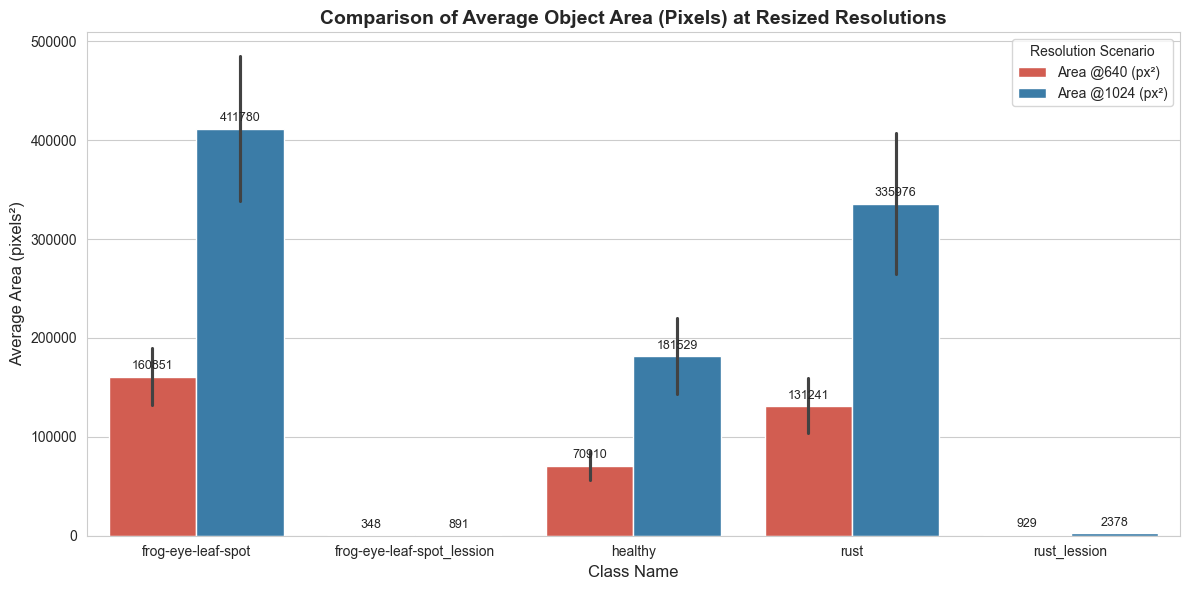

✅ Analisis Selesai.
💾 File tersimpan di: visualization_chart\object_size_analysis
   1. object_size_statistics.csv
   2. avg_object_area_comparison.png


In [19]:
import os
import glob
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm # Untuk progress bar

# --- UTILITY FUNCTIONS ---

def get_polygon_area(coords_norm, img_w, img_h):
    """
    Menghitung area poligon dari koordinat normalized YOLO (x1, y1, x2, y2, ...).
    Menggunakan Shoelace Formula.
    """
    # Reshape ke (N, 2) dan denormalize ke pixel asli
    coords = np.array(coords_norm).reshape(-1, 2)
    coords[:, 0] *= img_w
    coords[:, 1] *= img_h
    
    # Shoelace formula
    x = coords[:, 0]
    y = coords[:, 1]
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

def get_bbox_area(row_data, img_w, img_h):
    """
    Menghitung area bounding box dari format YOLO (class x y w h).
    """
    # row_data: [class, x_center, y_center, width, height]
    w_pixel = row_data[3] * img_w
    h_pixel = row_data[4] * img_h
    return w_pixel * h_pixel, w_pixel, h_pixel

def find_image_path(label_path):
    """
    Mencari path gambar berdasarkan path label.
    Mengganti 'labels' dengan 'images' dan mencoba berbagai ekstensi.
    """
    img_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
    base_path = str(label_path).replace(os.sep + 'labels' + os.sep, os.sep + 'images' + os.sep)
    base_path = os.path.splitext(base_path)[0]
    
    for ext in img_extensions:
        img_path = base_path + ext
        if os.path.exists(img_path):
            return img_path
    return None

def analyze_sizes(dataset_path, dataset_type):
    path = Path(dataset_path)
    data_yaml = path / "data.yaml"
    
    # Load Class Names
    class_names = {}
    if data_yaml.exists():
        with open(data_yaml, 'r') as f:
            data = yaml.safe_load(f)
            names = data.get('names', {})
            if isinstance(names, list):
                class_names = {i: n for i, n in enumerate(names)}
            else:
                class_names = names
    
    stats = []
    
    # Scan Train/Valid/Test
    splits = ['train', 'valid', 'test', 'val']
    
    print(f"🚀 Memproses dataset: {dataset_type} ({path.name})...")
    
    label_files = []
    for split in splits:
        label_dir = path / split / 'labels'
        if label_dir.exists():
            label_files.extend(glob.glob(str(label_dir / "*.txt")))
            
    # Proses setiap file label
    for label_file in tqdm(label_files, desc="Analyzing Images"):
        label_path = Path(label_file)
        
        # Cari gambar untuk dimensi asli
        img_path = find_image_path(label_path)
        if img_path:
            img = cv2.imread(img_path)
            if img is None: continue
            h_orig, w_orig, _ = img.shape
        else:
            # Jika gambar tidak ketemu, skip (atau bisa pakai default size jika mau maksa)
            continue
            
        with open(label_path, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            parts = [float(x) for x in line.strip().split()]
            cls_id = int(parts[0])
            cls_name = class_names.get(cls_id, str(cls_id))
            
            # Tentukan tipe anotasi (Box vs Polygon)
            # Box: class x y w h (5 value)
            # Mask: class x1 y1 x2 y2 ... (>5 value)
            
            area_orig = 0
            w_orig_obj = 0
            h_orig_obj = 0
            
            is_mask = len(parts) > 5
            
            if is_mask:
                # Hitung Area Mask
                area_orig = get_polygon_area(parts[1:], w_orig, h_orig)
                # Estimasi width/height mask dari bounding rect polygon (simplified)
                coords = np.array(parts[1:]).reshape(-1, 2)
                w_norm = coords[:, 0].max() - coords[:, 0].min()
                h_norm = coords[:, 1].max() - coords[:, 1].min()
                w_orig_obj = w_norm * w_orig
                h_orig_obj = h_norm * h_orig
                obj_type = "Mask"
            else:
                # Hitung Area BBox
                area_orig, w_orig_obj, h_orig_obj = get_bbox_area(parts, w_orig, h_orig)
                obj_type = "Bounding Box"
            
            # Hanya ambil data jika tipe dataset sesuai permintaan
            # (Seg path bisa berisi box, tapi kita fokus ke Mask jika itu dataset Seg)
            if dataset_type == "Segmentation" and not is_mask:
                continue
            if dataset_type == "Object Detection" and is_mask:
                continue # Harusnya tidak terjadi di folder obj det murni
                
            stats.append({
                'Class': cls_name,
                'Type': obj_type,
                'Img_W_Orig': w_orig,
                'Img_H_Orig': h_orig,
                'Obj_Area_Orig': area_orig,
                'Obj_W_Orig': w_orig_obj,
                'Obj_H_Orig': h_orig_obj
            })
            
    return pd.DataFrame(stats)

# --- MAIN EXECUTION ---

obj_det_path = "../dataset_collection/roboflow/object_detection/object_detection_all_class"
seg_path = "../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession"
output_folder = "visualization_chart/object_size_analysis"

# 1. Jalankan Analisis
df_det = analyze_sizes(obj_det_path, "Object Detection")
df_seg = analyze_sizes(seg_path, "Segmentation")

# Gabungkan Data
df_all = pd.concat([df_det, df_seg], ignore_index=True)

if df_all.empty:
    print("❌ Tidak ada data yang ditemukan. Periksa path folder.")
else:
    # 2. Kalkulasi Rata-Rata & Simulasi Resize
    # Kita hitung rasio area terhadap gambar asli, lalu kalikan ke resolusi target
    
    # Grouping
    grouped = df_all.groupby(['Class', 'Type']).agg({
        'Img_W_Orig': 'mean',
        'Img_H_Orig': 'mean',
        'Obj_Area_Orig': 'mean',
        'Obj_W_Orig': 'mean',
        'Obj_H_Orig': 'mean'
    }).reset_index()
    
    # Hitung Rasio Ukuran Objek terhadap Gambar Asli
    # Area Ratio = Obj_Area / (Img_W * Img_H)
    grouped['Img_Area_Orig'] = grouped['Img_W_Orig'] * grouped['Img_H_Orig']
    grouped['Area_Ratio'] = grouped['Obj_Area_Orig'] / grouped['Img_Area_Orig']
    
    # Hitung Estimasi Pixel pada 640x640 dan 1024x1024
    # Area_New = Area_Ratio * (Target_W * Target_H)
    grouped['Area_px_640'] = grouped['Area_Ratio'] * (640 * 640)
    grouped['Area_px_1024'] = grouped['Area_Ratio'] * (1024 * 1024)
    
    # Estimasi Sisi (Akar Kuadrat dari Area untuk representasi visual 'sisi kotak')
    grouped['Side_px_640'] = np.sqrt(grouped['Area_px_640'])
    grouped['Side_px_1024'] = np.sqrt(grouped['Area_px_1024'])

    # Format Tampilan Tabel agar Rapi
    final_table = grouped[[
        'Class', 'Type', 'Img_W_Orig', 'Obj_Area_Orig', 
        'Area_px_640', 'Side_px_640', 
        'Area_px_1024', 'Side_px_1024', 'Area_Ratio'
    ]].copy()
    
    final_table.columns = [
        'Class Name', 'Annotation Type', 'Avg Orig Img Width', 'Avg Orig Area (px²)',
        'Area @640 (px²)', 'Est. Side @640 (px)', 
        'Area @1024 (px²)', 'Est. Side @1024 (px)', 'Image Coverage (%)'
    ]
    final_table['Image Coverage (%)'] = final_table['Image Coverage (%)'] * 100

    # 3. Simpan Tabel
    out_path = Path(output_folder)
    out_path.mkdir(parents=True, exist_ok=True)
    
    csv_path = out_path / "object_size_statistics.csv"
    final_table.to_csv(csv_path, index=False)
    
    print("\n" + "="*80)
    print("📊 DATA TABLE: AVERAGE OBJECT SIZES")
    print("="*80)
    pd.set_option('display.float_format', '{:.2f}'.format)
    print(final_table.to_string(index=False))
    print("-" * 80)

    # 4. VISUALISASI GRAFIK (Bar Chart Compare 640 vs 1024)
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    
    # Melt data for visualization (Area @640 vs Area @1024)
    df_melted = final_table.melt(
        id_vars=['Class Name', 'Annotation Type'], 
        value_vars=['Area @640 (px²)', 'Area @1024 (px²)'],
        var_name='Resolution', value_name='Avg Area (px²)'
    )
    
    # Plot
    ax = sns.barplot(
        data=df_melted, 
        x='Class Name', 
        y='Avg Area (px²)', 
        hue='Resolution',
        palette=['#e74c3c', '#2980b9'] # Merah (640), Biru (1024)
    )
    
    plt.title('Comparison of Average Object Area (Pixels) at Resized Resolutions', fontsize=14, fontweight='bold')
    plt.xlabel('Class Name', fontsize=12)
    plt.ylabel('Average Area (pixels²)', fontsize=12)
    
    # Log scale jika perbedaan lesi vs daun terlalu jauh
    # plt.yscale('log') 
    
    # Tambahkan Label Angka
    for c in ax.containers:
        ax.bar_label(c, fmt='%.0f', padding=3, fontsize=9)
        
    plt.legend(title='Resolution Scenario')
    plt.tight_layout()
    
    chart_path = out_path / "avg_object_area_comparison.png"
    plt.savefig(chart_path, dpi=300)
    plt.show()
    
    print(f"✅ Analisis Selesai.")
    print(f"💾 File tersimpan di: {out_path}")
    print(f"   1. {csv_path.name}")
    print(f"   2. {chart_path.name}")

In [25]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO
from tqdm import tqdm
from pathlib import Path

# --- KONFIGURASI DAFTAR MODEL ---
# Format: "Nama Model": {"path": "path/ke/best.pt", "imgsz": ukuran_gambar}
MODELS_CONFIG = {
    # IMG SIZE 640
    "Nano (640)": {
        "path": r"../normal_segmentation_experiment/results/yolo_v11/segmentation_leaf_and_lession/training/nano/weights/best.pt",
        "imgsz": 640
    },
    "Small (640)": {
        "path": r"../normal_segmentation_experiment/results/yolo_v11/segmentation_leaf_and_lession/training/small/weights/best.pt",
        "imgsz": 640
    },
    "Medium (640)": {
        "path": r"../normal_segmentation_experiment/results/yolo_v11/segmentation_leaf_and_lession/training/medium/weights/best.pt",
        "imgsz": 640
    },
    
    # IMG SIZE 1024
    "Nano (1024)": {
        "path": r"../normal_segmentation_experiment/results/yolo_v11/segmentation_leaf_and_lession_imgsz/training/nano/weights/best.pt",
        "imgsz": 1024
    },
    "Small (1024)": {
        "path": "hardware tidak kuat",
        "imgsz": 1024
    },
    "Large (1024)": {
        "path": "hardware tidak kuat",
        "imgsz": 1024
    }
}

DATASET_ROOT = r"../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession"
DATA_YAML_PATH = os.path.join(DATASET_ROOT, "data.yaml")
OUTPUT_FOLDER = "visualization_chart"

# --- HELPER FUNCTIONS ---

def calculate_mask_metrics(gt_mask, pred_mask):
    """Menghitung IoU dan Dice Score pixel-level."""
    intersection = np.logical_and(gt_mask, pred_mask).sum()
    union = np.logical_or(gt_mask, pred_mask).sum()
    iou = intersection / (union + 1e-6)
    dice = (2. * intersection) / (gt_mask.sum() + pred_mask.sum() + 1e-6)
    return iou, dice

def polygon_to_mask(img_shape, polygon_coords):
    """Konversi polygon YOLO ke binary mask."""
    h, w = img_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    if len(polygon_coords) > 0:
        points = np.array(polygon_coords).reshape(-1, 2)
        points[:, 0] *= w
        points[:, 1] *= h
        points = points.astype(np.int32)
        cv2.fillPoly(mask, [points], 1)
    return mask

def evaluate_single_model(model_name, config, dataset_root, data_yaml):
    model_path = config["path"]
    img_size = config["imgsz"]

    # 1. Cek Ketersediaan Model
    if "hardware tidak kuat" in str(model_path) or not os.path.exists(model_path):
        print(f"\n⏭️ SKIP: {model_name} ({model_path})")
        return None

    print(f"\n🚀 START: Evaluasi Model {model_name} (Size: {img_size})...")
    
    model = YOLO(model_path)
    class_names = model.names
    
    # ---------------------------------------------------------
    # TAHAP 1: YOLO Validator (mAP, Precision, Recall)
    # ---------------------------------------------------------
    print("   Running YOLO Validation...")
    # Menjalankan validasi pada split test
    val_results = model.val(data=data_yaml, split='test', imgsz=img_size, verbose=False, save=False)
    
    # Extract Metrics (Arrays per class)
    # Box
    box_p = val_results.box.p    # Precision array
    box_r = val_results.box.r    # Recall array
    box_map = val_results.box.maps # mAP50-95 array
    
    # Mask
    seg_p = val_results.seg.p    # Precision array
    seg_r = val_results.seg.r    # Recall array
    seg_map = val_results.seg.maps # mAP50-95 array

    # ---------------------------------------------------------
    # TAHAP 2: Manual IoU & Dice Score (Pixel Level)
    # ---------------------------------------------------------
    print("   Calculating mIoU & Dice Score (Pixel-level)...")
    
    test_images = glob.glob(os.path.join(dataset_root, "test", "images", "*.*"))
    if not test_images:
        test_images = glob.glob(os.path.join(dataset_root, "valid", "images", "*.*"))
    
    class_metrics = {k: {'iou': [], 'dice': []} for k in class_names.keys()}
    
    for img_path in tqdm(test_images, desc=f"   {model_name}"):
        img = cv2.imread(img_path)
        if img is None: continue
        h, w = img.shape[:2]
        
        # Parse Label
        label_path = img_path.replace("images", "labels").rsplit('.', 1)[0] + ".txt"
        gt_polygons = {k: [] for k in class_names.keys()}
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = list(map(float, line.strip().split()))
                    cls_id = int(parts[0])
                    gt_polygons[cls_id].append(parts[1:])

        # Prediction
        results = model.predict(img, verbose=False, conf=0.25, imgsz=img_size)
        res = results[0]
        
        for cls_id in class_names.keys():
            # GT Mask
            mask_gt = np.zeros((h, w), dtype=np.uint8)
            for poly in gt_polygons[cls_id]:
                mask_gt = np.logical_or(mask_gt, polygon_to_mask((h, w), poly)).astype(np.uint8)
            
            # Pred Mask
            mask_pred = np.zeros((h, w), dtype=np.uint8)
            if res.masks is not None:
                for i, box_cls in enumerate(res.boxes.cls):
                    if int(box_cls) == cls_id:
                        m_data = res.masks.data[i].cpu().numpy()
                        m_resized = cv2.resize(m_data, (w, h), interpolation=cv2.INTER_NEAREST)
                        mask_pred = np.logical_or(mask_pred, m_resized).astype(np.uint8)
            
            if mask_gt.sum() == 0 and mask_pred.sum() == 0:
                continue
                
            iou, dice = calculate_mask_metrics(mask_gt, mask_pred)
            class_metrics[cls_id]['iou'].append(iou)
            class_metrics[cls_id]['dice'].append(dice)

    # ---------------------------------------------------------
    # TAHAP 3: Build DataFrame
    # ---------------------------------------------------------
    rows = []
    
    # 1. Per Class Data
    for cls_id, name in class_names.items():
        # IoU & Dice (Manual)
        ious = class_metrics[cls_id]['iou']
        dices = class_metrics[cls_id]['dice']
        avg_iou = np.mean(ious) if ious else 0.0
        avg_dice = np.mean(dices) if dices else 0.0
        
        # Ultralytics Metrics (Safe Access)
        b_p = box_p[cls_id] if cls_id < len(box_p) else 0.0
        b_r = box_r[cls_id] if cls_id < len(box_r) else 0.0
        b_map = box_map[cls_id] if cls_id < len(box_map) else 0.0
        
        s_p = seg_p[cls_id] if cls_id < len(seg_p) else 0.0
        s_r = seg_r[cls_id] if cls_id < len(seg_r) else 0.0
        s_map = seg_map[cls_id] if cls_id < len(seg_map) else 0.0
        
        rows.append({
            "Model": model_name,
            "Image Size": img_size,
            "Class": name,
            "Box Precision": b_p,
            "Box Recall": b_r,
            "Box mAP50-95": b_map,
            "Mask Precision": s_p,
            "Mask Recall": s_r,
            "Mask mAP50-95": s_map,
            "mIoU (Pixel)": avg_iou,
            "Dice Score": avg_dice
        })

    # 2. Mean Row (All Classes)
    # Gunakan atribut .mp, .mr, .map dari val_results untuk rata-rata global yang akurat
    df_temp = pd.DataFrame(rows)
    mean_row = {
        "Model": model_name,
        "Image Size": img_size,
        "Class": "ALL CLASSES (Mean)",
        "Box Precision": val_results.box.mp,
        "Box Recall": val_results.box.mr,
        "Box mAP50-95": val_results.box.map,
        "Mask Precision": val_results.seg.mp,
        "Mask Recall": val_results.seg.mr,
        "Mask mAP50-95": val_results.seg.map,
        "mIoU (Pixel)": df_temp["mIoU (Pixel)"].mean(),
        "Dice Score": df_temp["Dice Score"].mean()
    }
    rows.append(mean_row)
    
    return pd.DataFrame(rows)

# --- EKSEKUSI UTAMA ---

def main():
    all_results = []
    
    # Buat folder output
    Path(OUTPUT_FOLDER).mkdir(parents=True, exist_ok=True)

    # Loop semua model di konfigurasi
    for name, config in MODELS_CONFIG.items():
        df_model = evaluate_single_model(name, config, DATASET_ROOT, DATA_YAML_PATH)
        if df_model is not None:
            all_results.append(df_model)

    if not all_results:
        print("❌ Tidak ada model yang berhasil dievaluasi.")
        return

    # Gabungkan semua hasil
    final_df = pd.concat(all_results, ignore_index=True)

    # Rapikan urutan kolom
    cols = [
        "Model", "Image Size", "Class", 
        "Box Precision", "Box Recall", "Box mAP50-95", 
        "Mask Precision", "Mask Recall", "Mask mAP50-95", 
        "mIoU (Pixel)", "Dice Score"
    ]
    final_df = final_df[cols]

    # Tampilkan Preview
    print("\n" + "="*80)
    print("📊 FINAL COMPREHENSIVE METRICS (ALL MODELS)")
    print("="*80)
    # Tampilkan hanya baris 'ALL CLASSES' agar konsol tidak penuh
    pd.set_option('display.float_format', '{:.4f}'.format)
    print(final_df[final_df["Class"] == "ALL CLASSES (Mean)"])
    
    # Simpan ke CSV
    csv_path = os.path.join(OUTPUT_FOLDER, "comprehensive_model_comparison.csv")
    final_df.to_csv(csv_path, index=False)
    print(f"\n✅ Hasil lengkap disimpan di: {csv_path}")

if __name__ == "__main__":
    main()


🚀 START: Evaluasi Model Nano (640) (Size: 640)...
   Running YOLO Validation...
Ultralytics 8.4.0  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
YOLO11n-seg summary (fused): 113 layers, 2,835,543 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 3958.4718.9 MB/s, size: 837.4 KB)
val: Scanning C:\Users\abiyamf\Documents\Code Program\Thesis\dataset_collection\roboflow\segmentation\segmentation_mask_leaf_and_lession\test\labels.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.8it/s 3.5s.2ss
                   all        150        753      0.848       0.86      0.914      0.816      0.836       0.84      0.887      0.703
Speed: 1.0ms preprocess, 3.5ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to C:\Users\abiyamf\

   Nano (640): 100%|██████████| 150/150 [00:55<00:00,  2.69it/s]


🚀 START: Evaluasi Model Small (640) (Size: 640)...
   Running YOLO Validation...
Ultralytics 8.4.0  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)


YOLO11s-seg summary (fused): 113 layers, 10,068,751 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 3651.0907.0 MB/s, size: 823.5 KB)
val: Scanning C:\Users\abiyamf\Documents\Code Program\Thesis\dataset_collection\roboflow\segmentation\segmentation_mask_leaf_and_lession\test\labels.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.9it/s 3.5s.2ss
                   all        150        753      0.888      0.863      0.926      0.832      0.875      0.848        0.9      0.718
Speed: 1.1ms preprocess, 4.5ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to C:\Users\abiyamf\Documents\Code Program\Thesis\random_experiment\runs\segment\val6
   Calculating mIoU & Dice Score (Pixel-level)...


   Small (640): 100%|██████████| 150/150 [00:54<00:00,  2.73it/s]

...

   Medium (640): 100%|██████████| 150/150 [00:54<00:00,  2.73it/s]


🚀 START: Evaluasi Model Nano (1024) (Size: 1024)...
   Running YOLO Validation...
Ultralytics 8.4.0  Python-3.12.12 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
YOLO11n-seg summary (fused): 113 layers, 2,835,543 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 3382.1472.2 MB/s, size: 947.9 KB)
val: Scanning C:\Users\abiyamf\Documents\Code Program\Thesis\dataset_collection\roboflow\segmentation\segmentation_mask_leaf_and_lession\test\labels.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150  0.0s


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.7it/s 3.7s.2ss
                   all        150        753       0.88      0.868      0.912      0.815      0.887      0.866      0.914      0.758
Speed: 2.0ms preprocess, 3.1ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to C:\Users\abiyamf\Documents\Code Program\Thesis\random_experiment\runs\segment\val8
   Calculating mIoU & Dice Score (Pixel-level)...


   Nano (1024): 100%|██████████| 150/150 [00:53<00:00,  2.79it/s]


⏭️ SKIP: Small (1024) (hardware tidak kuat)

⏭️ SKIP: Large (1024) (hardware tidak kuat)

📊 FINAL COMPREHENSIVE METRICS (ALL MODELS)
           Model  Image Size               Class  Box Precision  Box Recall  \
5     Nano (640)         640  ALL CLASSES (Mean)         0.8482      0.8603   
11   Small (640)         640  ALL CLASSES (Mean)         0.8876      0.8631   
17  Medium (640)         640  ALL CLASSES (Mean)         0.9033      0.8455   
23   Nano (1024)        1024  ALL CLASSES (Mean)         0.8798      0.8680   

    Box mAP50-95  Mask Precision  Mask Recall  Mask mAP50-95  mIoU (Pixel)  \
5         0.8157          0.8361       0.8397         0.7035        0.6867   
11        0.8323          0.8751       0.8484         0.7175        0.7159   
17        0.8446          0.8980       0.8260         0.7297        0.7315   
23        0.8153          0.8872       0.8665         0.7579        0.7439   

    Dice Score  
5       0.7649  
11      0.7953  
17      0.8110  
23      0.8

Mencari performa terbaik (Peak mAP) dari folder Validation Scheme 1B...
 > Nano: Best at K=50 (mAP95: 0.7518, P: 0.7714, R: 0.7245)
 > Small: Best at K=35 (mAP95: 0.7658, P: 0.7749, R: 0.7779)
 > Medium: Best at K=40 (mAP95: 0.7619, P: 0.7819, R: 0.7289)

✅ File CSV berhasil disimpan di: visualization_chart\scheme_1B_best_metrics_summary.csv
--------------------------------------------------
Model Size  Best K-Shot  Precision  Recall  mAP50  mAP50-95
      Nano           50     0.7714  0.7245 0.8088    0.7518
     Small           35     0.7749  0.7779 0.8172    0.7658
    Medium           40     0.7819  0.7289 0.8253    0.7619
--------------------------------------------------


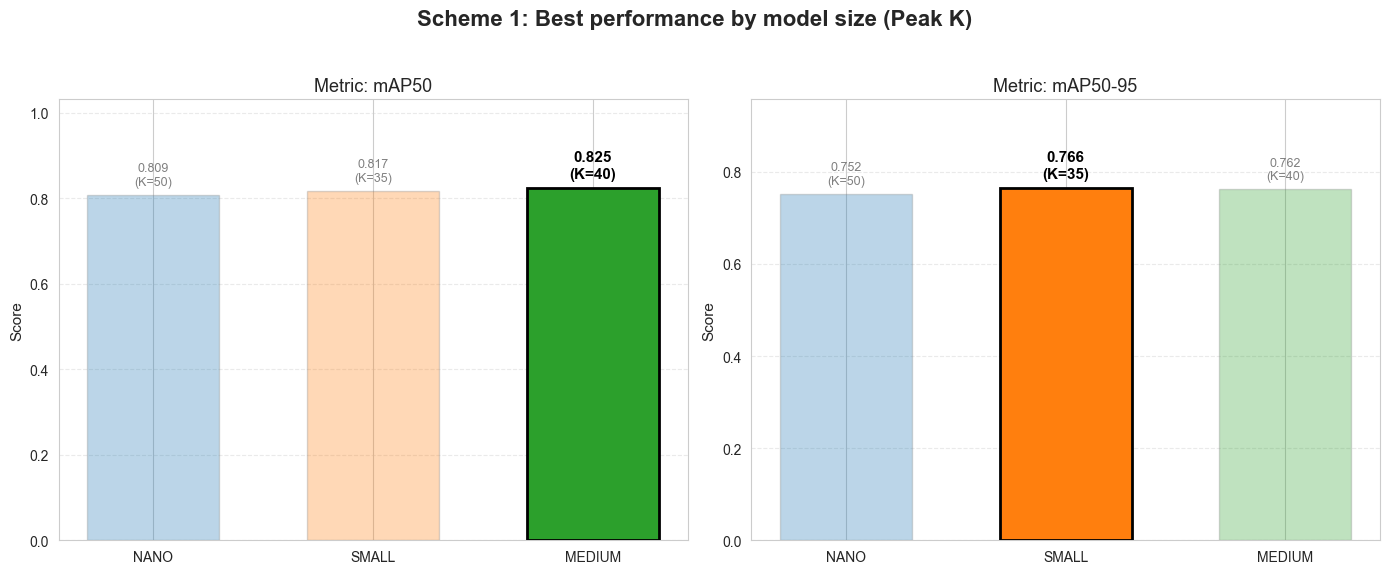

In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. KONFIGURASI ---
# Sesuaikan path ini dengan lokasi root folder results Anda
BASE_PATH_SCHEME_1B = "../few-shot_object_detection_experiment/results/yolo_v12/object_detection_novel_class_scheme-1B"
OUTPUT_CSV_DIR = "visualization_chart" # Folder untuk menyimpan hasil CSV
OUTPUT_FILENAME = "scheme_1B_best_metrics_summary.csv"

VARIANTS = ["nano", "small", "medium"]
K_VALUES = range(5, 51, 5) # 5, 10, ..., 50

# Palet Warna Standar
COLORS = {
    "nano":   "#1f77b4", # Biru
    "small":  "#ff7f0e", # Oranye
    "medium": "#2ca02c", # Hijau
}

# --- FUNGSI BANTU MEMBACA CSV ---
def load_metrics_from_csv(csv_path):
    """
    Membaca file class_metrics_validation.csv, mencari baris 'all',
    dan mengembalikan (precision, recall, mAP50, mAP50-95).
    """
    try:
        df = pd.read_csv(csv_path)
        # Bersihkan spasi pada nama kolom
        df.columns = [c.strip() for c in df.columns]
        
        # Cari baris dengan class == 'all'
        # Pastikan nama kolom 'class' sesuai dengan output CSV Anda (bisa 'class', 'Class', atau 'classes')
        if 'class' not in df.columns:
             return None, None, None, None

        row = df[df['class'] == 'all']
        
        if row.empty:
            return None, None, None, None
            
        r = row.iloc[0]
        
        # Ambil nilai metrics dan pastikan float
        # NOTE: Sesuaikan nama kolom ('precision', 'recall') jika di CSV Anda berbeda (misal 'P', 'R')
        prec = float(r['precision']) 
        rec = float(r['recall'])
        m50 = float(r['mAP50'])
        m95 = float(r['mAP50-95'])
        
        return prec, rec, m50, m95

    except Exception as e:
        # print(f"[ERR] Gagal membaca {csv_path}: {e}") 
        return None, None, None, None

# --- 2. PERSIAPAN DATA (MENCARI BEST K UNTUK SETIAP SIZE) ---
results_data = []

print("Mencari performa terbaik (Peak mAP) dari folder Validation Scheme 1B...")

for variant in VARIANTS:
    # Inisialisasi variabel pelacak terbaik
    best_stats = {
        "precision": 0.0,
        "recall": 0.0,
        "mAP50": 0.0,
        "mAP50-95": 0.0,
        "best_k": -1
    }
    found_any = False
    
    # Loop semua K-shot
    for k in K_VALUES:
        # Konstruksi Path
        csv_path = os.path.join(
            BASE_PATH_SCHEME_1B, 
            "validation", 
            f"{k}-shot", 
            variant, 
            "class_metrics_validation.csv"
        )
        
        if os.path.exists(csv_path):
            curr_p, curr_r, curr_map50, curr_map95 = load_metrics_from_csv(csv_path)
            
            if curr_map95 is not None:
                # Cek rekor baru berdasarkan mAP50-95 tertinggi
                if curr_map95 > best_stats["mAP50-95"]:
                    best_stats["mAP50-95"] = curr_map95
                    best_stats["mAP50"] = curr_map50
                    best_stats["precision"] = curr_p
                    best_stats["recall"] = curr_r
                    best_stats["best_k"] = k
                found_any = True
    
    # Simpan data terbaik untuk variant ini
    row_data = {"Model Size": variant.capitalize()}
    
    if found_any:
        row_data["Best K-Shot"] = best_stats["best_k"]
        row_data["Precision"] = best_stats["precision"]
        row_data["Recall"] = best_stats["recall"]
        row_data["mAP50"] = best_stats["mAP50"]
        row_data["mAP50-95"] = best_stats["mAP50-95"]
        
        print(f" > {variant.capitalize()}: Best at K={best_stats['best_k']} "
              f"(mAP95: {best_stats['mAP50-95']:.4f}, P: {best_stats['precision']:.4f}, R: {best_stats['recall']:.4f})")
    else:
        print(f" [SKIP] Data tidak ditemukan untuk {variant}")
        row_data["Best K-Shot"] = "N/A"
        row_data["Precision"] = np.nan
        row_data["Recall"] = np.nan
        row_data["mAP50"] = np.nan
        row_data["mAP50-95"] = np.nan
        
    results_data.append(row_data)

# Buat DataFrame
df = pd.DataFrame(results_data)

# --- 3. SIMPAN KE CSV ---
if not df.empty:
    # Buat folder jika belum ada
    os.makedirs(OUTPUT_CSV_DIR, exist_ok=True)
    full_save_path = os.path.join(OUTPUT_CSV_DIR, OUTPUT_FILENAME)
    
    # Atur urutan kolom agar rapi
    cols = ["Model Size", "Best K-Shot", "Precision", "Recall", "mAP50", "mAP50-95"]
    df = df[cols]
    
    # Simpan
    df.to_csv(full_save_path, index=False)
    print(f"\n✅ File CSV berhasil disimpan di: {full_save_path}")
    print("-" * 50)
    print(df.to_string(index=False))
    print("-" * 50)

# --- 4. VISUALISASI (Opsional: Tetap menampilkan mAP) ---
if not df.empty and not df['mAP50'].isnull().all():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Scheme 1: Best performance by model size (Peak K)", fontsize=16, fontweight='bold')

    metrics_to_plot = ["mAP50", "mAP50-95"]
    bar_w = 0.6 

    for ax, metric in zip(axes, metrics_to_plot):
        max_val = df[metric].max()
        
        for i, row in df.iterrows():
            variant = row['Model Size'].lower()
            val = row[metric]
            k_note = row['Best K-Shot']
            
            if pd.isna(val): continue

            is_best = np.isclose(val, max_val)
            
            # Style
            alpha = 1.0 if is_best else 0.3
            linewidth = 2.0 if is_best else 1.0
            edgecolor = 'black' if is_best else 'gray'
            zorder = 5 if is_best else 3

            # Plot
            bar = ax.bar(
                variant.upper(), 
                val, 
                color=COLORS.get(variant, "gray"),
                edgecolor=edgecolor,
                linewidth=linewidth,
                alpha=alpha,
                width=bar_w,
                zorder=zorder
            )
            
            # Annotasi
            display_text = f'{val:.3f}\n(K={k_note})'
            ax.text(
                bar[0].get_x() + bar[0].get_width()/2., 
                val + (max_val * 0.02), 
                display_text,
                ha='center', va='bottom', 
                fontsize=11 if is_best else 9,
                fontweight='bold' if is_best else 'normal',
                color='black' if is_best else 'gray'
            )

        ax.set_title(f"Metric: {metric}", fontsize=13)
        ax.set_ylabel("Score", fontsize=11)
        if not pd.isna(max_val):
            ax.set_ylim(0, max_val * 1.25)
        ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(OUTPUT_CSV_DIR, "scheme_1B_best_model_performance.png"), dpi=300)
    plt.show()

Mengklasifikasikan gambar berdasarkan nama file...
✅ Frog-eye Images : 50
✅ Rust Images     : 50

Processing Frog-eye...


100%|██████████| 50/50 [00:21<00:00,  2.31it/s]



Processing Rust...


100%|██████████| 50/50 [00:17<00:00,  2.83it/s]



Membuat Bar Chart...


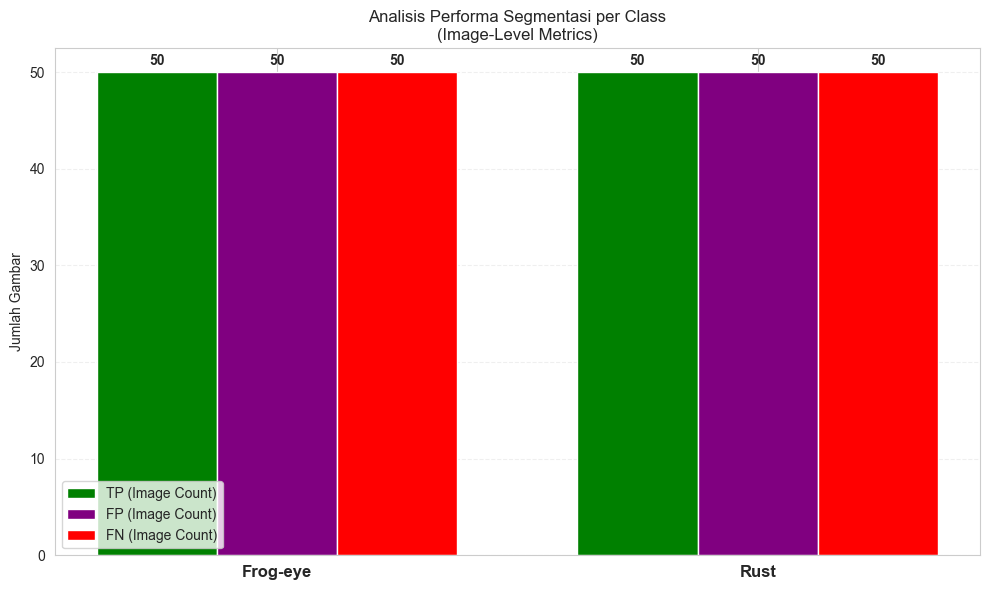


Membuat Visualisasi Sample...


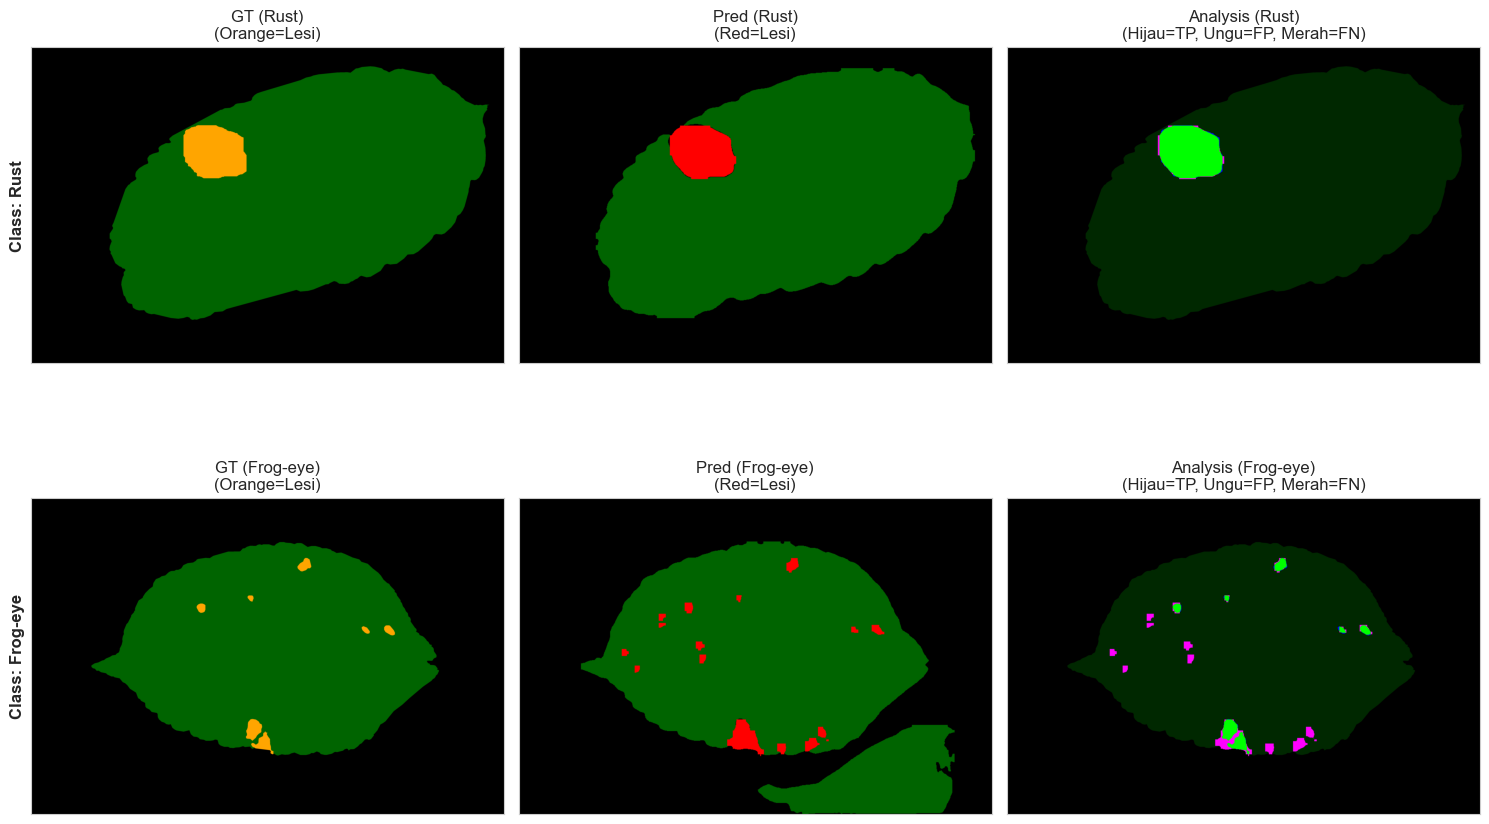


✅ Selesai. Hasil tersimpan di: visualization_chart/final_analysis_fixed/
REKAP STATISTIK:
{'Frog-eye': {'TP': 50, 'FP': 50, 'FN': 50, 'Total': 50}, 'Rust': {'TP': 50, 'FP': 50, 'FN': 50, 'Total': 50}}


In [33]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
from tqdm import tqdm

# --- 1. KONFIGURASI UTAMA ---
TEST_IMAGES_DIR = r"../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession/test/images"
TEST_LABELS_DIR = r"../dataset_collection/roboflow/segmentation/segmentation_mask_leaf_and_lession/test/labels"
MODEL_PATH = r"../severity_estimation_experiment/best_model/segmentation/single_module/leaf_and_lession.pt"
OUTPUT_DIR = "visualization_chart/final_analysis_fixed/"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- KONFIGURASI CLASS ID (UPDATED) ---
# Berdasarkan: ['frog-eye-leaf-spot', 'frog-eye-leaf-spot_lession', 'healthy', 'rust', 'rust_lession']

# Class ID untuk DAUN (Konteks/Background Daun)
# 0 = frog-eye-leaf-spot (daunnya)
# 2 = healthy
# 3 = rust (daunnya)
LEAF_CLASSES = [0, 2, 3]

# Class ID untuk LESI (Penyakit/Spot)
# 1 = frog-eye-leaf-spot_lession
# 4 = rust_lession
LESION_CLASSES = [1, 4]

# Warna Visualisasi
COLOR_TP = (0, 255, 0)   # Hijau (Benar)
COLOR_FP = (255, 0, 255) # Ungu (Salah Deteksi)
COLOR_FN = (0, 0, 255)   # Merah (Gagal Deteksi)
COLOR_GT_LESION = (255, 165, 0) # Orange (Ground Truth Asli)
COLOR_GT_LEAF = (0, 100, 0) # Hijau Gelap (Daun)

def get_label_path(img_path):
    filename = os.path.basename(img_path)
    base, _ = os.path.splitext(filename)
    return os.path.join(TEST_LABELS_DIR, base + ".txt")

def create_masks(img_shape, label_path):
    h, w = img_shape[:2]
    leaf_mask = np.zeros((h, w), dtype=np.uint8)
    lesion_mask = np.zeros((h, w), dtype=np.uint8)
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = list(map(float, line.strip().split()))
                cls_id = int(parts[0])
                
                coords = np.array(parts[1:]).reshape(-1, 2)
                coords[:, 0] *= w
                coords[:, 1] *= h
                pts = coords.astype(np.int32).reshape((-1, 1, 2))

                if cls_id in LEAF_CLASSES:
                    cv2.fillPoly(leaf_mask, [pts], 1)
                elif cls_id in LESION_CLASSES:
                    cv2.fillPoly(lesion_mask, [pts], 1)
    
    return leaf_mask, lesion_mask

def analyze_image(img_path, model):
    img = cv2.imread(img_path)
    if img is None: return None, None, None, None
    h, w = img.shape[:2]
    
    label_path = get_label_path(img_path)
    
    # 1. Generate GT
    gt_leaf, gt_lesion = create_masks((h, w), label_path)

    # 2. Prediction
    results = model(img, verbose=False, conf=0.15)[0]
    pred_leaf = np.zeros((h, w), dtype=np.uint8)
    pred_lesion = np.zeros((h, w), dtype=np.uint8)

    if results.masks is not None:
        polygons = results.masks.xy
        classes = results.boxes.cls.cpu().numpy()
        
        for poly, cls_id in zip(polygons, classes):
            # Pastikan poligon valid
            if len(poly) > 0:
                pts = np.array([poly], dtype=np.int32)
                
                if cls_id in LEAF_CLASSES:
                    cv2.fillPoly(pred_leaf, [pts], 1)
                elif cls_id in LESION_CLASSES:
                    cv2.fillPoly(pred_lesion, [pts], 1)

    # 3. Hitung Pixel-Level Logic
    # TP: Ada di GT DAN Ada di Pred
    tp_mask = np.logical_and(gt_lesion, pred_lesion)
    # FP: Tidak ada di GT TAPI Ada di Pred
    fp_mask = np.logical_and(np.logical_not(gt_lesion), pred_lesion)
    # FN: Ada di GT TAPI Tidak ada di Pred
    fn_mask = np.logical_and(gt_lesion, np.logical_not(pred_lesion))

    # 4. Konversi ke IMAGE-LEVEL Logic (Boolean)
    has_tp = np.sum(tp_mask) > 0
    has_fp = np.sum(fp_mask) > 0
    has_fn = np.sum(fn_mask) > 0

    # 5. Buat Visualisasi (Hanya jika perlu untuk plotting nanti)
    # Visual GT
    vis_gt = np.zeros((h, w, 3), dtype=np.uint8)
    vis_gt[gt_leaf == 1] = COLOR_GT_LEAF
    vis_gt[gt_lesion == 1] = COLOR_GT_LESION

    # Visual Pred
    vis_pred = np.zeros((h, w, 3), dtype=np.uint8)
    vis_pred[pred_leaf == 1] = COLOR_GT_LEAF
    vis_pred[pred_lesion == 1] = (255, 0, 0) # Merah Polos untuk prediksi mentah

    # Visual Error Analysis
    vis_error = np.zeros((h, w, 3), dtype=np.uint8)
    vis_error[gt_leaf == 1] = (0, 40, 0) # Background Daun Redup
    vis_error[tp_mask] = COLOR_TP
    vis_error[fp_mask] = COLOR_FP
    vis_error[fn_mask] = COLOR_FN

    return has_tp, has_fp, has_fn, (vis_gt, vis_pred, vis_error)

def main():
    model = YOLO(MODEL_PATH)

    # 1. Load Semua Gambar
    all_images = glob.glob(os.path.join(TEST_IMAGES_DIR, "*.*"))
    valid_ext = ['.jpg', '.jpeg', '.png']
    all_images = [f for f in all_images if os.path.splitext(f)[1].lower() in valid_ext]
    
    if not all_images:
        print("❌ Error: Folder gambar kosong atau path salah.")
        return

    # 2. Klasifikasi Berdasarkan Filename (Substring)
    frog_images = []
    rust_images = []

    print("Mengklasifikasikan gambar berdasarkan nama file...")
    for img_path in all_images:
        fname = os.path.basename(img_path).lower()
        if "frog_eye" in fname:
            frog_images.append(img_path)
        elif "rust" in fname:
            rust_images.append(img_path)
    
    print(f"✅ Frog-eye Images : {len(frog_images)}")
    print(f"✅ Rust Images     : {len(rust_images)}")

    # 3. Analisis Per Class
    stats = {
        'Frog-eye': {'TP': 0, 'FP': 0, 'FN': 0, 'Total': 0},
        'Rust':     {'TP': 0, 'FP': 0, 'FN': 0, 'Total': 0}
    }

    # Helper untuk process loop
    def process_list(image_list, class_name):
        print(f"\nProcessing {class_name}...")
        sample_visuals = None # Simpan 1 sample untuk visualisasi nanti
        
        for img_path in tqdm(image_list):
            has_tp, has_fp, has_fn, visuals = analyze_image(img_path, model)
            if has_tp is None: continue

            stats[class_name]['Total'] += 1
            if has_tp: stats[class_name]['TP'] += 1
            if has_fp: stats[class_name]['FP'] += 1
            if has_fn: stats[class_name]['FN'] += 1
            
            # Simpan visualisasi terakhir yang punya error (biar menarik)
            if has_fp or has_fn:
                sample_visuals = visuals
        
        return sample_visuals

    # Run Analysis
    vis_frog = process_list(frog_images, 'Frog-eye')
    vis_rust = process_list(rust_images, 'Rust')

    # 4. Generate Grouped Bar Chart
    print("\nMembuat Bar Chart...")
    
    categories = ['Frog-eye', 'Rust']
    
    tp_vals = [stats['Frog-eye']['TP'], stats['Rust']['TP']]
    fp_vals = [stats['Frog-eye']['FP'], stats['Rust']['FP']]
    fn_vals = [stats['Frog-eye']['FN'], stats['Rust']['FN']]
    
    x = np.arange(len(categories))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))
    
    rects1 = ax.bar(x - width, tp_vals, width, label='TP (Image Count)', color='green')
    rects2 = ax.bar(x,         fp_vals, width, label='FP (Image Count)', color='purple')
    rects3 = ax.bar(x + width, fn_vals, width, label='FN (Image Count)', color='red')

    ax.set_ylabel('Jumlah Gambar')
    ax.set_title('Analisis Performa Segmentasi per Class\n(Image-Level Metrics)')
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate('{}'.format(height),
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)

    plt.tight_layout()
    chart_path = os.path.join(OUTPUT_DIR, "grouped_barchart_fixed.png")
    plt.savefig(chart_path, dpi=300)
    plt.show()
    
    # 5. Generate Sample Visualizations (1 Frog, 1 Rust)
    if vis_frog and vis_rust:
        print("\nMembuat Visualisasi Sample...")
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Rust Row (Row 0)
        axes[0, 0].imshow(vis_rust[0])
        axes[0, 0].set_title("GT (Rust)\n(Orange=Lesi)")
        axes[0, 1].imshow(vis_rust[1])
        axes[0, 1].set_title("Pred (Rust)\n(Red=Lesi)")
        axes[0, 2].imshow(vis_rust[2])
        axes[0, 2].set_title("Analysis (Rust)\n(Hijau=TP, Ungu=FP, Merah=FN)")
        axes[0, 0].set_ylabel("Class: Rust", fontweight='bold', fontsize=12)

        # Frog Row (Row 1)
        axes[1, 0].imshow(vis_frog[0])
        axes[1, 0].set_title("GT (Frog-eye)\n(Orange=Lesi)")
        axes[1, 1].imshow(vis_frog[1])
        axes[1, 1].set_title("Pred (Frog-eye)\n(Red=Lesi)")
        axes[1, 2].imshow(vis_frog[2])
        axes[1, 2].set_title("Analysis (Frog-eye)\n(Hijau=TP, Ungu=FP, Merah=FN)")
        axes[1, 0].set_ylabel("Class: Frog-eye", fontweight='bold', fontsize=12)

        for ax_row in axes:
            for ax in ax_row:
                ax.set_xticks([])
                ax.set_yticks([])

        plt.tight_layout()
        viz_path = os.path.join(OUTPUT_DIR, "sample_comparison_fixed.png")
        plt.savefig(viz_path, dpi=300)
        plt.show()

    print(f"\n✅ Selesai. Hasil tersimpan di: {OUTPUT_DIR}")
    print("="*50)
    print("REKAP STATISTIK:")
    print(stats)

if __name__ == "__main__":
    main()